In [83]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [86]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [87]:
df.describe(include= object)

C:\Users\pc\AppData\Local\Temp\ipykernel_25912\3779998608.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include= object)


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [88]:
df.duplicated().sum()

np.int64(1)

1 row repeated

In [89]:
df.drop_duplicates() # drop the duplicates
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [90]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

no NaN values

In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [92]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [93]:
df.boxplot(column='charges')

<Axes: >

In [94]:
df.charges.describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

In [95]:
charges_IQR = 16657.717450 - 4746.344000
charges_max_lim = 16657.717450 + 1.5 * charges_IQR
charges_min_lim = 4746.344000 - 1.5 * charges_IQR
print(f"charges_max_lim = {charges_max_lim}")
print(f"charges_min_lim = {charges_min_lim}")

charges_max_lim = 34524.777625
charges_min_lim = -13120.716174999998


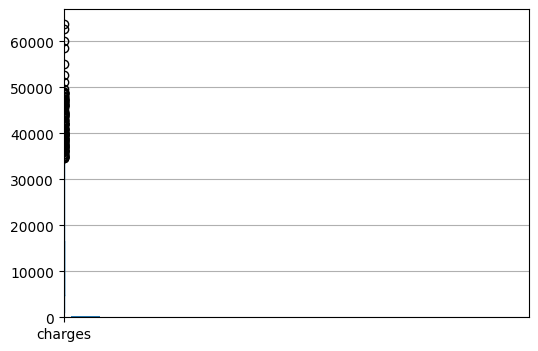

In [96]:
df['charges'].hist(bins=30, figsize=(6,4))
plt.show()


C:\Users\pc\AppData\Local\Temp\ipykernel_25912\1540030929.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['charges'], shade=True)


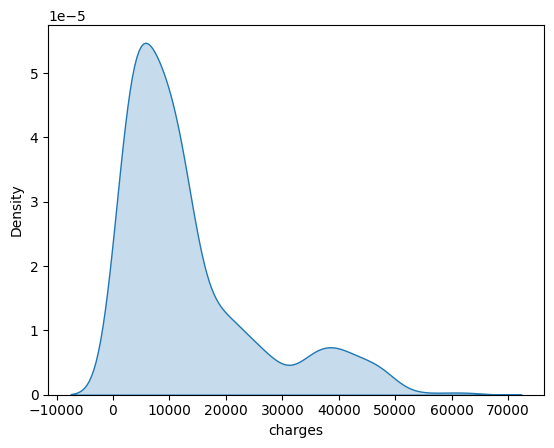

In [97]:
sns.kdeplot(df['charges'], shade=True)
plt.show()


In [98]:
# numerical   correlations

In [99]:
df.boxplot(column='age')

<Axes: >

In [100]:
df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

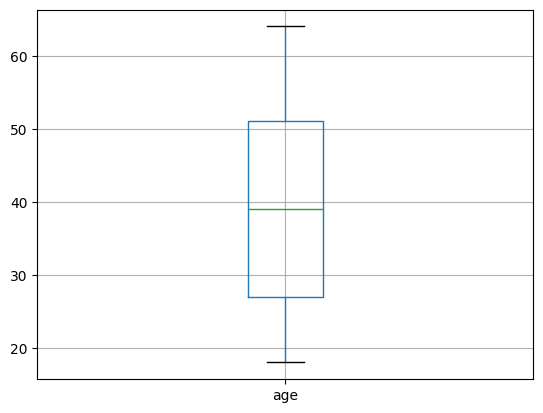

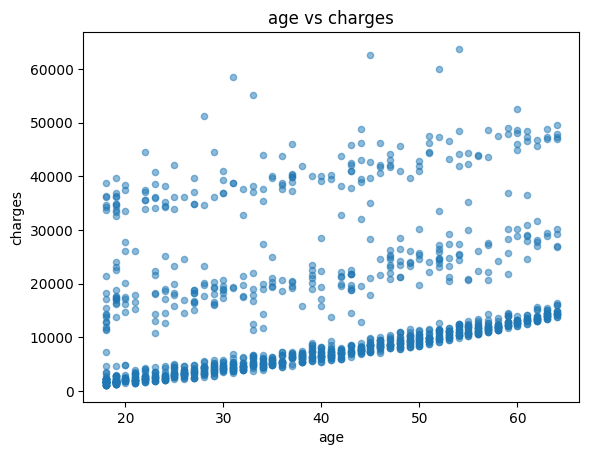

In [101]:
df.plot(kind='scatter', x='age', y='charges', alpha=0.5)
plt.title("age vs charges")
plt.show()

In [102]:
df.boxplot(column='bmi')

<Axes: >

In [103]:
df.bmi.describe()

count    1338.000000
mean       30.663397
std         6.098187
min        15.960000
25%        26.296250
50%        30.400000
75%        34.693750
max        53.130000
Name: bmi, dtype: float64

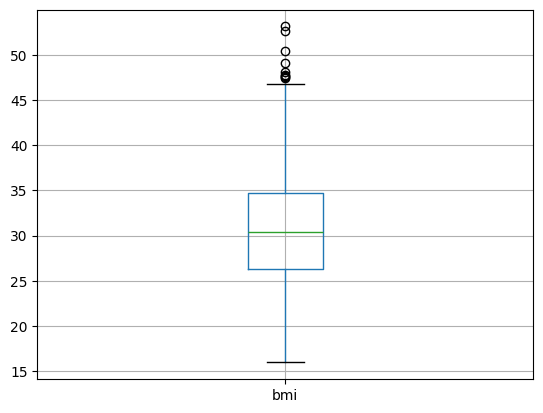

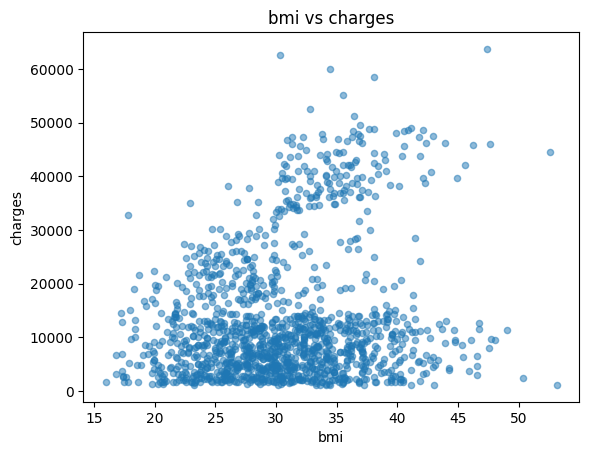

In [104]:
df.plot(kind='scatter', x='bmi', y='charges', alpha=0.5)
plt.title("bmi vs charges")
plt.show()

In [105]:
df.boxplot(column='children')

<Axes: >

In [106]:
df.children.describe()

count    1338.000000
mean        1.094918
std         1.205493
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

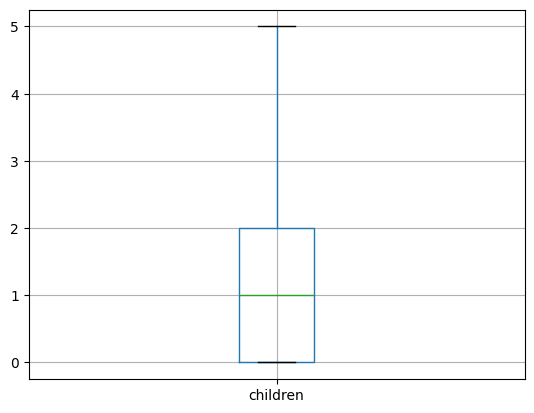

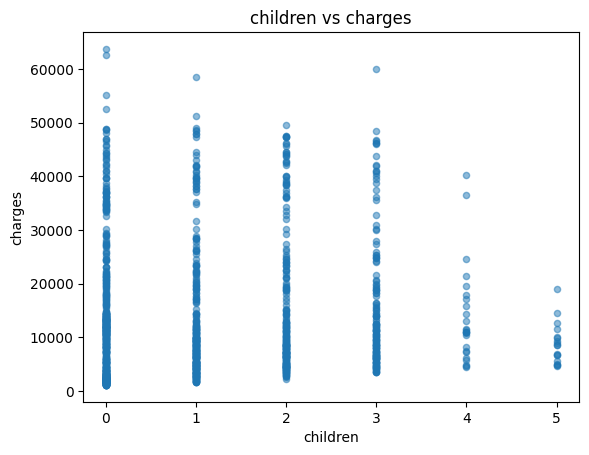

In [107]:
df.plot(kind='scatter', x='children', y='charges', alpha=0.5)
plt.title("children vs charges")
plt.show()

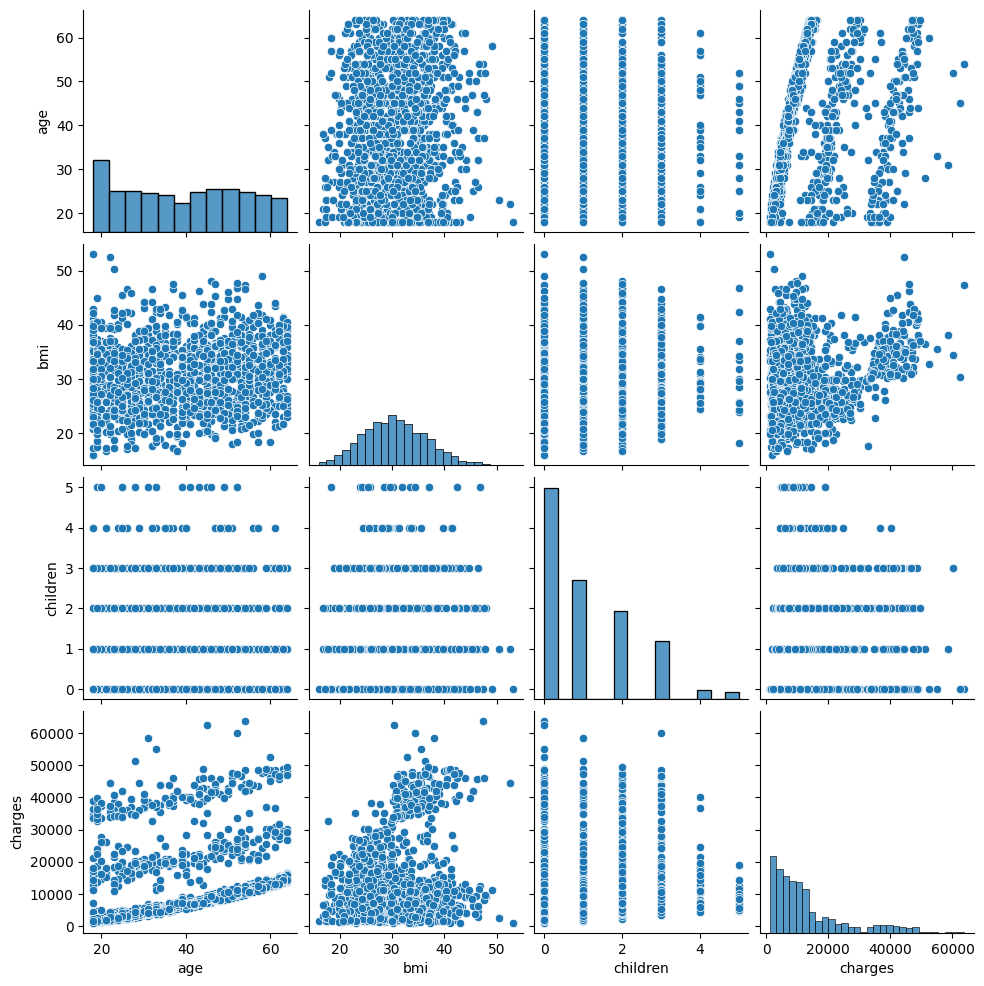

In [108]:
sns.pairplot(data=df)
plt.show()

In [109]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [110]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: >

In [111]:
# categorical  correlations

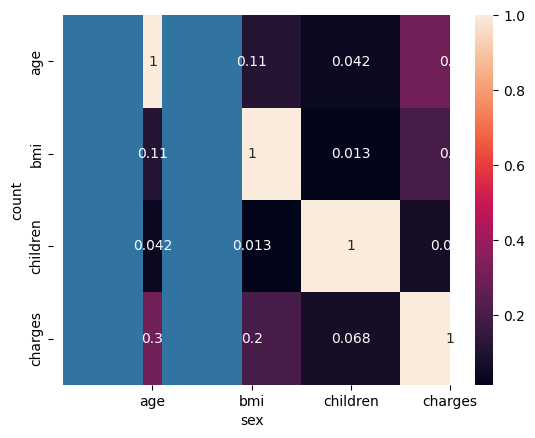

In [112]:
sns.countplot(x='sex', data=df)
plt.show()

In [113]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [114]:
sex_pct = df['sex'].value_counts(normalize=True) * 100
sex_pct

sex
male      50.523169
female    49.476831
Name: proportion, dtype: float64

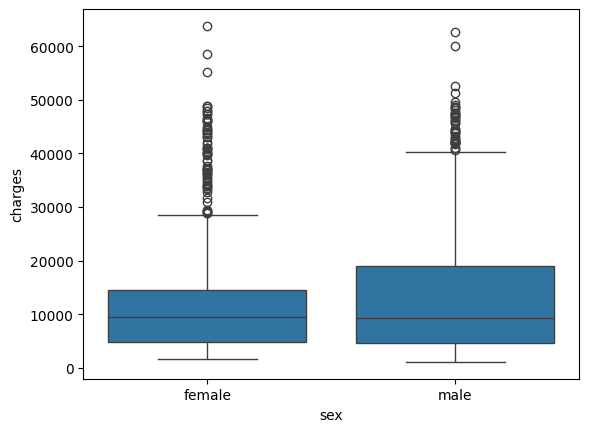

In [115]:
sns.boxplot(x='sex', y='charges', data=df)
plt.show()

In [116]:
df.groupby('sex')['charges'].mean()

sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64

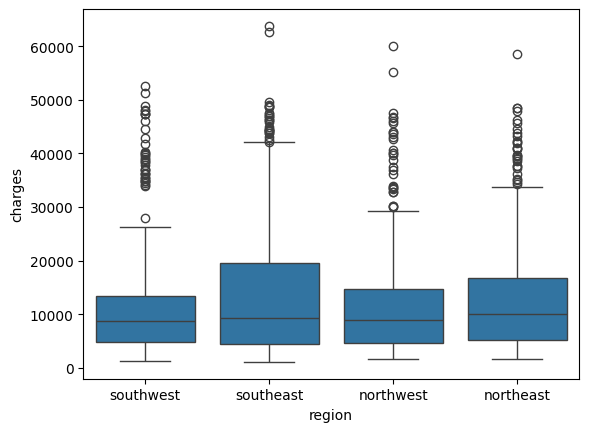

In [117]:
sns.boxplot(x='region', y='charges', data=df)
plt.show()

In [118]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [119]:
region_pct = df['region'].value_counts(normalize=True) * 100
region_pct

region
southeast    27.204783
southwest    24.289985
northwest    24.289985
northeast    24.215247
Name: proportion, dtype: float64

In [120]:
df.groupby('region')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384516,11255.803066,1694.7964,5194.322288,10057.652025,16687.3641,58571.07448
northwest,325.0,12417.575374,11072.276928,1621.3402,4719.736550,8965.795750,14711.7438,60021.39897
southeast,364.0,14735.411438,13971.098589,1121.8739,4440.886200,9294.131950,19526.2869,63770.42801
southwest,325.0,12346.937377,11557.179101,1241.5650,4751.070000,8798.593000,13462.5200,52590.82939


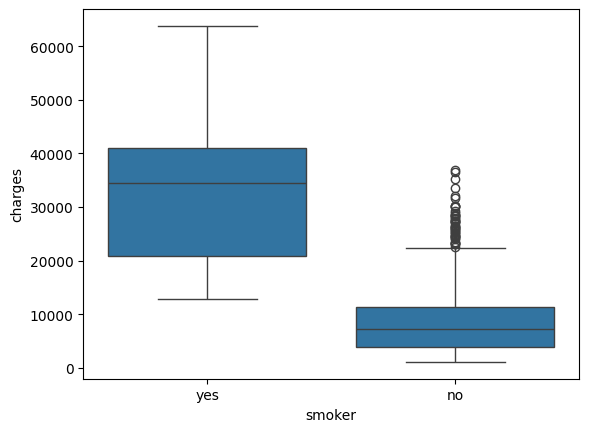

In [121]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

In [122]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [123]:
smoker_pct = df['smoker'].value_counts(normalize=True) * 100
smoker_pct

smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64

In [124]:
df.groupby('smoker')['charges'].mean()

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [125]:
print(f"""
the numerical columns that has the outliers
    ==> the charges column
    ==> the bmi column
the numerical columns that has no the outliers
    ==> the age column
    ==> the children column

the most numerical column that influence on the charges column
    ==> the age column
the most categorical column that influence on the charges column
    ==> the smoker column


""")


the numerical columns that has the outliers
    ==> the charges column
    ==> the bmi column
the numerical columns that has no the outliers
    ==> the age column
    ==> the children column

the most numerical column that influence on the charges column
    ==> the age column
the most categorical column that influence on the charges column
    ==> the smoker column





In [126]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [140]:
df['region_w'] = df['region'].map({
    'southeast': 1, 
    'northwest': 2, 
    'northeast': 3, 
    'southwest': 4, 
}).fillna(0)
df.groupby("sex").sex.count()
s = df.corr(method='pearson', numeric_only=True)
p = df.corr(method='spearman', numeric_only=True)
x = df.age.corr(df.bmi)
# p = df.age.rank()
print(s)
print(p)
print(x)

               age       bmi  children   charges  region_w
age       1.000000  0.109272  0.042469  0.299008  0.013120
bmi       0.109272  1.000000  0.012759  0.198341 -0.163359
children  0.042469  0.012759  1.000000  0.067998  0.017063
charges   0.299008  0.198341  0.067998  1.000000 -0.059500
region_w  0.013120 -0.163359  0.017063 -0.059500  1.000000
               age       bmi  children   charges  region_w
age       1.000000  0.107736  0.056992  0.534392  0.016119
bmi       0.107736  1.000000  0.015607  0.119396 -0.150335
children  0.056992  0.015607  1.000000  0.133339  0.006992
charges   0.534392  0.119396  0.133339  1.000000 -0.021468
region_w  0.016119 -0.150335  0.006992 -0.021468  1.000000
0.10927188154853519


In [133]:
c = df.age.cov(df.bmi)
c


np.float64(9.362336626407425)